# IFN680 Project 5 — Task 2 -  Reverse Addition + Subtraction LLM

This notebook implements **Task 2** of IFN680 Project 5.

It extends the Forward addition/subtraction model developed in Task 1 by changing the **target prediction order** while preserving the remainder of the modelling setup as closely as possible.

In Forward mode, the answer is generated in normal left-to-right order:

`12+19= → 31`

In Reverse mode, the target sequence is reversed:

`12+19= → 13`

The model therefore predicts the units digit before the tens digit, more closely matching the direction in which manual addition and subtraction handle carries and borrows.

The arithmetic problems, tokenizer, Transformer architecture, optimiser, train/validation/test design and evaluation methodology are otherwise retained from the Forward implementation. This allows prediction direction to remain the principal experimental difference between the two models.

For negative answers, this notebook interprets "reverse target sequence" literally and reverses the complete answer string:

`123-456=-333 → 333-`

After generation, the predicted sequence is reversed again before conversion to its normal numeric representation.

Shared code lives in `project5_common.py`. If you edit that file after importing, restart the kernel or `importlib.reload(p5)`.

## 1. Environment and reproducibility

Same setup as Forward, except the checkpoint path.

In [1]:
import importlib
import random
import math
import time
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F
from tqdm.auto import tqdm

import project5_common as p5
importlib.reload(p5)

SEED = 680
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MODEL_PATH = Path("LLMReverse.pth")
SPLITS_PATH = p5.SPLITS_PATH
TEST_DATA_PATH = p5.TEST_DATA_PATH

# Reverse mode: reverse answer strings for training targets;
# restore by reversing again before numeric parsing (later sections).
TARGET_TRANSFORM = p5.reverse_target
RESTORE_PREDICTION = p5.reverse_target

print(f"MODEL_PATH = {MODEL_PATH}")
print(f"TARGET_TRANSFORM example: '-337' -> {TARGET_TRANSFORM('-337')!r}")

Using device: cuda
MODEL_PATH = LLMReverse.pth
TARGET_TRANSFORM example: '-337' -> '733-'


## 2. Shared implementation

Tokenizer, architecture, generation and evaluation helpers are imported from `project5_common` — identical to Forward.

In [2]:
tokenizer = p5.build_tokenizer()
ntokens = tokenizer.ntokens

print(f"Vocabulary ({ntokens} tokens): {tokenizer.vocab}")
print("Token IDs:", tokenizer.token_to_id)

Vocabulary (15 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']
Token IDs: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '+': 10, '-': 11, '=': 12, '[PAD]': 13, '[EOS]': 14}


### 2.1 Tokenizer sanity checks

In [3]:
examples = ["12+19=", "500-123=", "123-456=", "-333"]
for text in examples:
    encoded = tokenizer.encode(text)
    decoded = tokenizer.decode(encoded)
    print(f"{text!r:12} -> {encoded} -> {decoded!r}")

'12+19='     -> [1, 2, 10, 1, 9, 12] -> '12+19='
'500-123='   -> [5, 0, 0, 11, 1, 2, 3, 12] -> '500-123='
'123-456='   -> [1, 2, 3, 11, 4, 5, 6, 12] -> '123-456='
'-333'       -> [11, 3, 3, 3] -> '-333'


## 3. Synthetic arithmetic dataset

Load the **same** shared splits used by Forward. Answers remain in normal form in the dataset; Reverse only changes how targets are presented at batching time.

In [4]:
data_train, data_val, data_test = p5.load_or_create_splits(
    splits_path=SPLITS_PATH,
    test_path=TEST_DATA_PATH,
    seed=SEED,
)
p5.summarise_splits(data_train, data_val, data_test)

Train: 50,000
Validation: 10,000
Test: 10,000
Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0
train: addition=25,000, subtraction=25,000
val  : addition=5,000, subtraction=5,000
test : addition=5,000, subtraction=5,000


### 3.1 Carry and borrow descriptors

Unchanged from Forward.

In [5]:
sanity_examples = [
    p5.convert_datapoint(12, 19, "+"),
    p5.convert_datapoint(123, 456, "+"),
    p5.convert_datapoint(500, 123, "-"),
    p5.convert_datapoint(123, 456, "-"),
]

for prompt, answer in sanity_examples:
    print(
        f"{prompt}{answer:<6} | "
        f"carries={p5.count_carries(prompt)} | "
        f"borrows={p5.count_borrows(prompt)}"
    )

12+19=31     | carries=1 | borrows=0
123+456=579    | carries=0 | borrows=0
500-123=377    | carries=0 | borrows=2
123-456=-333   | carries=0 | borrows=3


### 3.4 Reverse target representation

The underlying arithmetic dataset is unchanged from the Forward model.

Reverse mode changes only the **representation of the target answer**. Each normal answer string is reversed before being supplied to the model.

| Arithmetic prompt | Normal result | Reverse target |
| --- | ---: | --- |
| `12+19=` | `31` | `13` |
| `627+501=` | `1128` | `8211` |
| `557-360=` | `197` | `791` |
| `524-861=` | `-337` | `733-` |

The complete string is reversed, including the negative sign. This creates a deterministic transformation that can be reversed again during inference.

In [6]:
def to_reverse_target(answer):
    """Convert a normal arithmetic answer to Reverse-mode target order."""
    return p5.reverse_target(answer)


reverse_examples = [
    ("12+19=", "31"),
    ("627+501=", "1128"),
    ("557-360=", "197"),
    ("524-861=", "-337"),
]

for prompt, answer in reverse_examples:
    print(
        f"{prompt:<10} "
        f"normal={answer:<6} "
        f"reverse={to_reverse_target(answer)}"
    )

12+19=     normal=31     reverse=13
627+501=   normal=1128   reverse=8211
557-360=   normal=197    reverse=791
524-861=   normal=-337   reverse=733-


## 4–6. Shared Transformer and generation

Architecture and `generate()` are identical to Forward. Instantiated here only to confirm the shared stack loads.

In [7]:
MODEL_CONFIG = p5.model_config(ntokens)
model = p5.TransformerModel(**MODEL_CONFIG).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model.__class__.__module__ + "." + model.__class__.__name__)

Parameters: 502,671
project5_common.TransformerModel


/home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/project5_common.py:443: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## 7. Padding and batching for Reverse targets

Prompt padding remains unchanged from the Forward implementation.

The only Task 2 change occurs when the target answer is prepared. Before tokenisation, each answer string is reversed so that the model learns to generate the result from right to left.

For example:

`12+19=31`

is represented during Reverse-mode training as:

`12+19=13[EOS]`

and:

`123-456=-333`

is represented as:

`123-456=333-[EOS]`

Padding and `[EOS]` handling otherwise remain unchanged.

In [8]:
batch_size = p5.DEFAULT_BATCH_SIZE

X, Y, length_prompts, length_answers = p5.get_batch(
    reverse_examples,
    0,
    batch_size=len(reverse_examples),
    tokenizer=tokenizer,
    target_transform=TARGET_TRANSFORM,
)

print("Prompt batch shape:", X.shape)
print("Answer batch shape:", Y.shape)
print("Max prompt length:", length_prompts)
print("Max answer character length:", length_answers)
print()

for i in range(len(reverse_examples)):
    prompt_tokens = X[:, i].tolist()
    answer_tokens = Y[:, i].tolist()

    prompt_text = tokenizer.decode(
        [
            token
            for token in prompt_tokens
            if token != tokenizer.token_to_id[p5.PAD_TOKEN]
        ]
    )

    answer_text = tokenizer.decode(
        [
            token
            for token in answer_tokens
            if token not in {
                tokenizer.token_to_id[p5.PAD_TOKEN],
                tokenizer.token_to_id[p5.EOS_TOKEN],
            }
        ]
    )

    print(f"{prompt_text:<10} target={answer_text}")

Prompt batch shape: torch.Size([8, 4])
Answer batch shape: torch.Size([5, 4])
Max prompt length: 8
Max answer character length: 4

12+19=     target=13
627+501=   target=8211
557-360=   target=791
524-861=   target=733-


## Checkpoint — stop before training

At this stage we have verified:

- `31 → 13`
- `1128 → 8211`
- `197 → 791`
- `-337 → 733-`

into the training batch pipeline via `p5.get_batch(..., target_transform=p5.reverse_target)`.

**Do not train yet.** Next step: review Sections 8–9 against Forward (they should stay nearly identical, using the same `TARGET_TRANSFORM`), then train `LLMReverse.pth`.

## 8. Reverse-mode autoregressive evaluation

Training-time evaluation uses the shared autoregressive evaluator from `project5_common`.

The evaluation mechanics are identical to Forward mode. The only difference is that the expected target sequence is transformed using `TARGET_TRANSFORM`.

For example:

`12+19=31`

is evaluated in Reverse target space as:

`12+19=13[EOS]`

Token accuracy measures individual generated target tokens, while sequence accuracy requires the complete reversed answer sequence to match.

The generated sequence is **not yet converted back to normal numeric order** during training-time validation. Numeric restoration is introduced later for formal held-out evaluation.

In [9]:
print("Shared evaluator:", p5.evaluate_autoregressive.__name__)

print(
    "Reverse target example:",
    "31",
    "->",
    TARGET_TRANSFORM("31")
)

print(
    "Negative reverse target:",
    "-337",
    "->",
    TARGET_TRANSFORM("-337")
)

Shared evaluator: evaluate_autoregressive
Reverse target example: 31 -> 13
Negative reverse target: -337 -> 733-


## 9. Train the Reverse model

The Reverse model uses the same Transformer architecture, optimiser, learning rate, batch size and tutorial-style teacher-forced next-token training used by the Forward model.

The experimental change is limited to the target representation:

- **Forward:** `31[EOS]`
- **Reverse:** `13[EOS]`

The arithmetic prompts themselves remain unchanged.

During batching, `TARGET_TRANSFORM` reverses each normal answer string before tokenisation. Training therefore teaches the model to generate the rightmost arithmetic digit first.

As in Task 1, validation data are used to monitor convergence and select the best checkpoint. The model with the highest Reverse validation sequence accuracy is saved as `LLMReverse.pth`.

A maximum of 20 epochs is retained so that the Forward and Reverse training conditions remain directly comparable.

In [10]:
import math
import time

from torch.nn import functional as F
from tqdm.auto import tqdm


# ============================================================
# Reverse-model training configuration
# ============================================================

learning_rate = 1e-3
epochs = 20
batch_size = p5.DEFAULT_BATCH_SIZE


# Start from a fresh model.
model = p5.TransformerModel(
    **MODEL_CONFIG
).to(device)


# Same optimiser as Forward/tutorial.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)


history = {
    "train_loss": [],
    "val_loss": [],
    "train_token_accuracy": [],
    "val_token_accuracy": [],
    "train_sequence_accuracy": [],
    "val_sequence_accuracy": [],
}


best_val_sequence_accuracy = -1.0
best_epoch = 0


print(f"Training on: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"Training examples: {len(data_train):,}")
print(f"Validation examples: {len(data_val):,}")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Target mode: Reverse")
print()

# ------------------------------------------------------------
# Train one epoch
# ------------------------------------------------------------

def train_epoch():

    model.train()

    total_loss = 0.0
    n_batches = 0

    random.shuffle(data_train)

    progress = tqdm(
        range(0, len(data_train), batch_size),
        total=math.ceil(len(data_train) / batch_size),
        desc="Training",
        leave=False,
    )


    for i in progress:

        prompts, target_answers, length_prompts, length_answers = p5.get_batch(
            data_train,
            i,
            batch_size,
            tokenizer,
            TARGET_TRANSFORM,
        )

        prompts = prompts.to(device)
        target_answers = target_answers.to(device)


        # Tutorial-style teacher forcing:
        #
        # Reverse example:
        #
        # prompt:
        #     12+19=
        #
        # normal result:
        #     31
        #
        # training target:
        #     13[EOS]
        #
        input_tensor = torch.cat(
            (prompts, target_answers),
            0,
        )


        optimizer.zero_grad()


        output, _, _ = model(
            input_tensor
        )


        # Output at '=' predicts the first Reverse target token.
        output_answers = output[
            length_prompts - 1:-1,
            :,
            :
        ].reshape(
            -1,
            ntokens,
        )


        target_flat = target_answers.reshape(-1)


        loss = F.cross_entropy(
            output_answers,
            target_flat,
        )


        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        n_batches += 1

        progress.set_postfix(
            loss=f"{total_loss / n_batches:.4f}"
        )


    return total_loss / n_batches

# ------------------------------------------------------------
# Teacher-forced validation loss
# ------------------------------------------------------------

def validation_loss():

    model.eval()

    total_loss = 0.0
    n_batches = 0

    progress = tqdm(
        range(0, len(data_val), batch_size),
        total=math.ceil(len(data_val) / batch_size),
        desc="Validation loss",
        leave=False,
    )


    with torch.no_grad():

        for i in progress:

            prompts, target_answers, length_prompts, length_answers = p5.get_batch(
                data_val,
                i,
                batch_size,
                tokenizer,
                TARGET_TRANSFORM,
            )

            prompts = prompts.to(device)
            target_answers = target_answers.to(device)


            input_tensor = torch.cat(
                (prompts, target_answers),
                0,
            )


            output, _, _ = model(
                input_tensor
            )


            output_answers = output[
                length_prompts - 1:-1,
                :,
                :
            ].reshape(
                -1,
                ntokens,
            )


            target_flat = target_answers.reshape(-1)


            loss = F.cross_entropy(
                output_answers,
                target_flat,
            )


            total_loss += loss.item()
            n_batches += 1


    return total_loss / n_batches

Training on: cuda
GPU: NVIDIA A16-4Q
Training examples: 50,000
Validation examples: 10,000
Batch size: 100
Epochs: 20
Learning rate: 0.001
Target mode: Reverse



Pre training sanity check

In [11]:
prompts, target_answers, length_prompts, length_answers = p5.get_batch(
    data_train,
    0,
    batch_size,
    tokenizer,
    TARGET_TRANSFORM,
)

print("Prompt tensor shape:", prompts.shape)
print("Target tensor shape:", target_answers.shape)

print(
    "Model parameter device:",
    next(model.parameters()).device
)

print(
    "Reverse target transform:",
    "-337",
    "->",
    TARGET_TRANSFORM("-337")
)

Prompt tensor shape: torch.Size([8, 100])
Target tensor shape: torch.Size([5, 100])
Model parameter device: cuda:0
Reverse target transform: -337 -> 733-


In [12]:
# ============================================================
# Full Reverse training loop
# ============================================================

training_start_time = time.time()


for epoch in range(1, epochs + 1):

    epoch_start_time = time.time()


    # --------------------------------------------------------
    # Training and validation loss
    # --------------------------------------------------------

    train_loss = train_epoch()

    val_loss = validation_loss()


    # --------------------------------------------------------
    # Autoregressive accuracy
    #
    # TARGET_TRANSFORM ensures accuracy is measured against
    # Reverse-order answer sequences.
    # --------------------------------------------------------

    train_token_accuracy, train_sequence_accuracy = (
        p5.evaluate_autoregressive(
            model,
            data_train,
            tokenizer,
            device,
            target_transform=TARGET_TRANSFORM,
            batch_size=batch_size,
            desc=f"Epoch {epoch:02d} train accuracy",
        )
    )


    val_token_accuracy, val_sequence_accuracy = (
        p5.evaluate_autoregressive(
            model,
            data_val,
            tokenizer,
            device,
            target_transform=TARGET_TRANSFORM,
            batch_size=batch_size,
            desc=f"Epoch {epoch:02d} val accuracy",
        )
    )


    # --------------------------------------------------------
    # Record history
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_token_accuracy"].append(
        train_token_accuracy
    )

    history["val_token_accuracy"].append(
        val_token_accuracy
    )

    history["train_sequence_accuracy"].append(
        train_sequence_accuracy
    )

    history["val_sequence_accuracy"].append(
        val_sequence_accuracy
    )


    # --------------------------------------------------------
    # Save best Reverse checkpoint
    # --------------------------------------------------------

    checkpoint_saved = ""


    if val_sequence_accuracy > best_val_sequence_accuracy:

        best_val_sequence_accuracy = val_sequence_accuracy
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            MODEL_PATH,
        )

        checkpoint_saved = " <-- saved best model"


    epoch_time = time.time() - epoch_start_time


    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train token acc: {train_token_accuracy:.4f} | "
        f"Val token acc: {val_token_accuracy:.4f} | "
        f"Train seq acc: {train_sequence_accuracy:.4f} | "
        f"Val seq acc: {val_sequence_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{checkpoint_saved}"
    )


total_training_time = (
    time.time() - training_start_time
) / 60


print()
print("Reverse training complete.")
print(f"Total training time: {total_training_time:.2f} min")
print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)
print(f"Best epoch: {best_epoch}")
print(f"Saved checkpoint: {MODEL_PATH}")

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 01 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01/20 | Train loss: 1.3319 | Val loss: 1.0876 | Train token acc: 0.4793 | Val token acc: 0.4838 | Train seq acc: 0.0067 | Val seq acc: 0.0084 | Time: 21.6s <-- saved best model


...

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 20 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/20 | Train loss: 0.1989 | Val loss: 0.0245 | Train token acc: 0.9928 | Val token acc: 0.9923 | Train seq acc: 0.9751 | Val seq acc: 0.9738 | Time: 21.4s <-- saved best model

Reverse training complete.
Total training time: 7.12 min
Best validation sequence accuracy: 0.9738
Best epoch: 20
Saved checkpoint: LLMReverse.pth


### 9.1 Reverse-model training convergence

Training and validation loss, together with complete-sequence accuracy, are plotted to inspect whether the Reverse model has converged.

The Reverse model exhibits a delayed learning transition: sequence accuracy remains relatively low for much of training before increasing sharply in the final epochs.

The held-out test set is not used to determine whether further training is required. Any decision to continue training is based only on the training and validation curves.

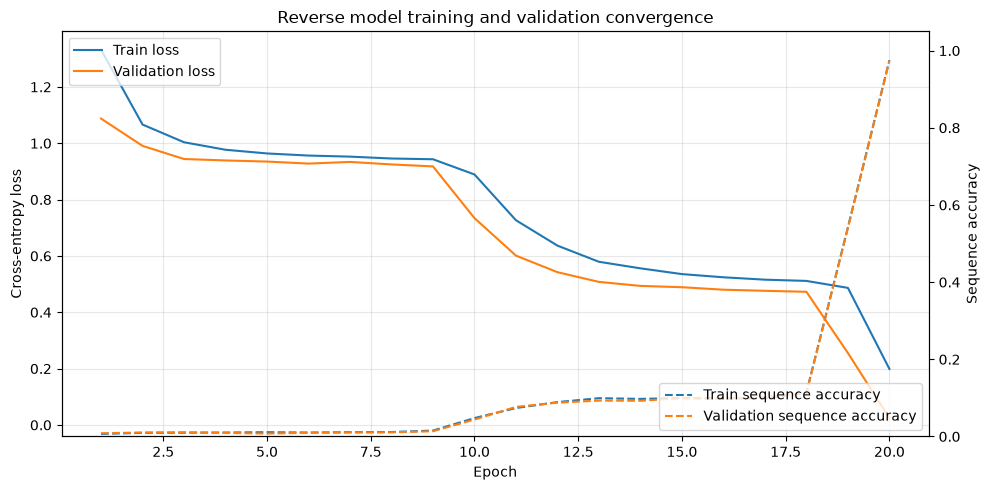

Best validation sequence accuracy: 0.9738
Best epoch: 20


In [13]:
import matplotlib.pyplot as plt

epoch_axis = np.arange(
    1,
    len(history["train_loss"]) + 1
)

fig, ax1 = plt.subplots(
    figsize=(10, 5)
)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

ax1.plot(
    epoch_axis,
    history["train_loss"],
    label="Train loss"
)

ax1.plot(
    epoch_axis,
    history["val_loss"],
    label="Validation loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")


# ------------------------------------------------------------
# Complete-sequence accuracy
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    epoch_axis,
    history["train_sequence_accuracy"],
    linestyle="--",
    label="Train sequence accuracy"
)

ax2.plot(
    epoch_axis,
    history["val_sequence_accuracy"],
    linestyle="--",
    label="Validation sequence accuracy"
)

ax2.set_ylabel("Sequence accuracy")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="lower right")


plt.title(
    "Reverse model training and validation convergence"
)

plt.tight_layout()
plt.show()


print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

In [14]:
additional_epochs = 5

start_epoch = len(
    history["train_loss"]
) + 1

end_epoch = (
    start_epoch
    + additional_epochs
)


for epoch in range(
    start_epoch,
    end_epoch
):

    epoch_start_time = time.time()


    train_loss = train_epoch()
    val_loss = validation_loss()


    train_token_accuracy, train_sequence_accuracy = (
        p5.evaluate_autoregressive(
            model,
            data_train,
            tokenizer,
            device,
            target_transform=TARGET_TRANSFORM,
            batch_size=batch_size,
            desc=f"Epoch {epoch:02d} train accuracy",
        )
    )


    val_token_accuracy, val_sequence_accuracy = (
        p5.evaluate_autoregressive(
            model,
            data_val,
            tokenizer,
            device,
            target_transform=TARGET_TRANSFORM,
            batch_size=batch_size,
            desc=f"Epoch {epoch:02d} val accuracy",
        )
    )


    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_token_accuracy"].append(
        train_token_accuracy
    )

    history["val_token_accuracy"].append(
        val_token_accuracy
    )

    history["train_sequence_accuracy"].append(
        train_sequence_accuracy
    )

    history["val_sequence_accuracy"].append(
        val_sequence_accuracy
    )


    checkpoint_saved = ""


    if val_sequence_accuracy > best_val_sequence_accuracy:

        best_val_sequence_accuracy = val_sequence_accuracy
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            MODEL_PATH,
        )

        checkpoint_saved = " <-- saved best model"


    epoch_time = (
        time.time()
        - epoch_start_time
    )


    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train token acc: {train_token_accuracy:.4f} | "
        f"Val token acc: {val_token_accuracy:.4f} | "
        f"Train seq acc: {train_sequence_accuracy:.4f} | "
        f"Val seq acc: {val_sequence_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{checkpoint_saved}"
    )


print()
print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 21 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 21 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 21 | Train loss: 0.0993 | Val loss: 0.0125 | Train token acc: 0.9976 | Val token acc: 0.9970 | Train seq acc: 0.9913 | Val seq acc: 0.9887 | Time: 21.4s <-- saved best model


...

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 25 train accuracy:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 25 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 25 | Train loss: 0.0529 | Val loss: 0.0078 | Train token acc: 0.9983 | Val token acc: 0.9977 | Train seq acc: 0.9939 | Val seq acc: 0.9914 | Time: 21.3s

Best validation sequence accuracy: 0.9937
Best epoch: 23


### 9.3 Final Reverse-model convergence

After the validation-driven continuation, the complete 25-epoch training history is plotted again.

The final model checkpoint is selected from all epochs using validation complete-sequence accuracy. No held-out test examples are used for this selection.

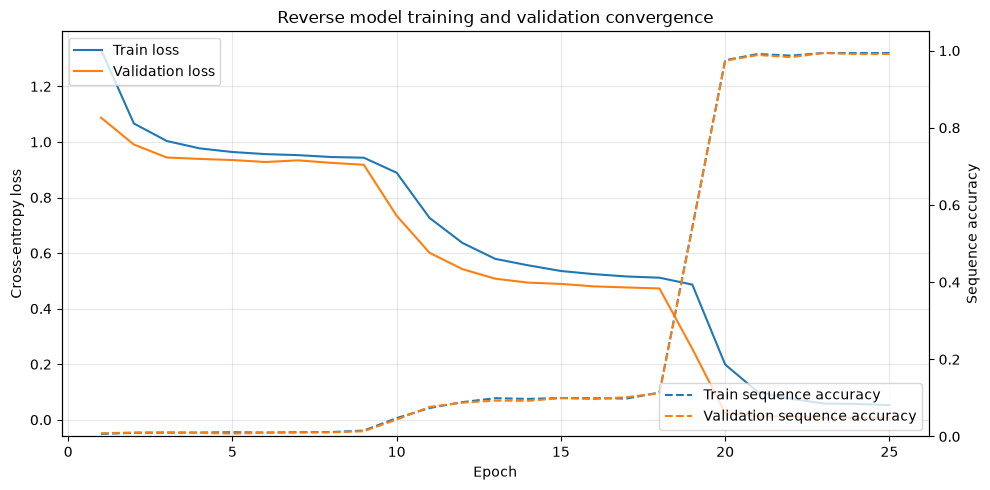

Final training epochs: 25
Best validation sequence accuracy: 0.9937
Best epoch: 23


In [15]:
epoch_axis = np.arange(
    1,
    len(history["train_loss"]) + 1
)

fig, ax1 = plt.subplots(
    figsize=(10, 5)
)


# Loss
ax1.plot(
    epoch_axis,
    history["train_loss"],
    label="Train loss"
)

ax1.plot(
    epoch_axis,
    history["val_loss"],
    label="Validation loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")


# Sequence accuracy
ax2 = ax1.twinx()

ax2.plot(
    epoch_axis,
    history["train_sequence_accuracy"],
    linestyle="--",
    label="Train sequence accuracy"
)

ax2.plot(
    epoch_axis,
    history["val_sequence_accuracy"],
    linestyle="--",
    label="Validation sequence accuracy"
)

ax2.set_ylabel("Sequence accuracy")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="lower right")


plt.title(
    "Reverse model training and validation convergence"
)

plt.tight_layout()
plt.show()


print(
    f"Final training epochs: "
    f"{len(history['train_loss'])}"
)

print(
    f"Best validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

## 10. Load the best Reverse validation checkpoint

The Reverse checkpoint with the highest validation complete-sequence accuracy is reloaded before inference.

Checkpoint selection uses validation performance only. The held-out Project 5 test set remains untouched until the Reverse model configuration and training are finalised.

In [16]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()


print(
    f"Loaded checkpoint: "
    f"{MODEL_PATH}"
)

print(
    f"Model device: "
    f"{next(model.parameters()).device}"
)

print(
    f"Selected validation sequence accuracy: "
    f"{best_val_sequence_accuracy:.4f}"
)

print(
    f"Selected epoch: "
    f"{best_epoch}"
)

Loaded checkpoint: LLMReverse.pth
Model device: cuda:0
Selected validation sequence accuracy: 0.9937
Selected epoch: 23


## 11. Reverse-mode numeric inference

The Reverse model generates answer characters in reversed order.

For example, a normal result of:

`-337`

is represented during training and generation as:

`733-`

Before numerical evaluation, the generated sequence must therefore be restored to normal order:

`733- → -337`

The shared inference functions support this through a `restore_prediction` transformation.

Because the Reverse transformation is its own inverse, the same `reverse_target()` function used during training can also restore generated predictions to conventional numeric order.

In [17]:
RESTORE_PREDICTION = p5.reverse_target


examples = [
    "12+19=",
    "999+999=",
    "500-123=",
    "500-278=",
    "123-456=",
    "0-999=",
]


for prompt in examples:

    predicted, restored, raw = p5.predict_sample(
        model,
        prompt,
        tokenizer,
        restore_prediction=RESTORE_PREDICTION,
        device=device,
    )


    a, operation, b = p5.parse_prompt(
        prompt
    )


    actual = (
        a + b
        if operation == "+"
        else a - b
    )


    status = (
        "CORRECT"
        if predicted == actual
        else "WRONG"
    )


    print(
        f"{prompt:<10} "
        f"raw={raw!r:<8} "
        f"restored={restored!r:<8} "
        f"predicted={str(predicted):<6} "
        f"actual={actual:<6} "
        f"{status}"
    )

12+19=     raw='23330'  restored='03332'  predicted=3332   actual=31     WRONG
999+999=   raw='8991'   restored='1998'   predicted=1998   actual=1998   CORRECT
500-123=   raw='773'    restored='377'    predicted=377    actual=377    CORRECT
500-278=   raw='222'    restored='222'    predicted=222    actual=222    CORRECT
123-456=   raw='333-'   restored='-333'   predicted=-333   actual=-333   CORRECT
0-999=     raw='99998'  restored='89999'  predicted=89999  actual=-999   WRONG


## 12. Formal held-out Reverse evaluation

The selected Reverse checkpoint is now evaluated on the fixed **10,000-example held-out test set** shared with the Forward model.

The test set contains:

- 5,000 addition examples;
- 5,000 subtraction examples;
- no overlap with training or validation data.

The Reverse model generates answers in reversed target order. Before numerical comparison, each generated answer is restored to conventional order using `reverse_target()`.

The primary metric is **exact numeric accuracy**:

`predicted integer == ground-truth integer`

The test set has not been used for training, epoch selection or checkpoint selection.

In [18]:
test_records = p5.predict_dataset(
    model,
    data_test,
    tokenizer,
    restore_prediction=RESTORE_PREDICTION,
    batch_size=batch_size,
    max_new_tokens=p5.DEFAULT_MAX_NEW_TOKENS,
    device=device,
)


addition_records = p5.subset(
    test_records,
    lambda r: r["operation"] == "+"
)

subtraction_records = p5.subset(
    test_records,
    lambda r: r["operation"] == "-"
)


overall_accuracy = p5.accuracy(
    test_records
)

addition_accuracy = p5.accuracy(
    addition_records
)

subtraction_accuracy = p5.accuracy(
    subtraction_records
)


malformed_predictions = sum(
    record["predicted"] is None
    for record in test_records
)


print(
    f"Overall exact numeric accuracy: "
    f"{overall_accuracy * 100:.2f}%"
)

print(
    f"Addition accuracy:             "
    f"{addition_accuracy * 100:.2f}%"
)

print(
    f"Subtraction accuracy:          "
    f"{subtraction_accuracy * 100:.2f}%"
)

print(
    f"Malformed predictions:         "
    f"{malformed_predictions:,}"
)

Predict:   0%|          | 0/100 [00:00<?, ?it/s]

Overall exact numeric accuracy: 99.25%
Addition accuracy:             99.44%
Subtraction accuracy:          99.06%
Malformed predictions:         0


### 12.1 Digit-position performance

Task 3 requires performance to be analysed across arithmetic digit positions.

Digit accuracy is calculated on the **normal restored numeric result**, not on the reversed generation sequence. This allows Forward and Reverse models to be compared using the same semantic positions:

- units;
- tens;
- hundreds;
- thousands.

For negative results, digits are evaluated using the absolute magnitude and sign correctness is measured separately.

A digit position contributes only when it exists in the ground-truth result.

In [19]:
print(
    f"{'Metric':<15}"
    f"{'All':>20}"
    f"{'Addition':>20}"
    f"{'Subtraction':>20}"
)

print("-" * 75)


for name, position in p5.DIGIT_POSITIONS.items():

    all_acc, all_n = p5.digit_position_accuracy(
        test_records,
        position
    )

    add_acc, add_n = p5.digit_position_accuracy(
        addition_records,
        position
    )

    sub_acc, sub_n = p5.digit_position_accuracy(
        subtraction_records,
        position
    )


    def format_metric(acc, n):

        if acc is None:
            return "N/A"

        return f"{acc * 100:.2f}% (n={n})"


    print(
        f"{name:<15}"
        f"{format_metric(all_acc, all_n):>20}"
        f"{format_metric(add_acc, add_n):>20}"
        f"{format_metric(sub_acc, sub_n):>20}"
    )


# ------------------------------------------------------------
# Subtraction sign performance
# ------------------------------------------------------------

sign_correct = 0
sign_total = 0

negative_exact_correct = 0
negative_total = 0


for record in subtraction_records:

    actual = record["actual"]
    predicted = record["predicted"]


    if predicted is not None:

        actual_negative = actual < 0
        predicted_negative = predicted < 0

        sign_correct += (
            actual_negative
            == predicted_negative
        )

        sign_total += 1


    if actual < 0:

        negative_total += 1

        if predicted == actual:
            negative_exact_correct += 1


sign_accuracy = (
    sign_correct / sign_total
)

negative_exact_accuracy = (
    negative_exact_correct
    / negative_total
)


print()

print(
    f"Subtraction sign accuracy: "
    f"{sign_accuracy * 100:.2f}%"
)

print(
    f"Negative-result exact accuracy: "
    f"{negative_exact_accuracy * 100:.2f}%"
)

Metric                          All            Addition         Subtraction
---------------------------------------------------------------------------
Units              99.93% (n=10000)     99.94% (n=5000)     99.92% (n=5000)
Tens                99.55% (n=9892)     99.48% (n=5000)     99.61% (n=4892)
Hundreds            99.78% (n=9004)     99.98% (n=4970)     99.53% (n=4034)
Thousands          100.00% (n=2502)    100.00% (n=2502)                 N/A

Subtraction sign accuracy: 99.88%
Negative-result exact accuracy: 99.52%
